# 재활용 이미지 분류 예측

- 라이브러리 불러오기
- 재활용 이미지 데이터 불러오기
- Train / Valid / Test 데이터 분리
- 클래스 분포 확인
- DataLoader 생성
- 이미지 데이터 확인
- CNN 모델 정의
- 손실함수 / Optimizer / Scheduler
- EarlyStopping
- 학습 및 평가 함수
- 모델 학습
- 학습 결과 시각화
- Test 최종 평가
- 예측 결과 수집
- Confusion Matrix
- 예측 이미지 확인
- 오분류 이미지 확인
- 단일 이미지 예측

## 데이터셋 

**Garbage Classification Dataset** (Kaggle)

- 재활용 가능한 쓰레기를 재질별로 분류하기 위한 이미지 데이터셋입니다.
- 총 6개 클래스, 2527장의 컬러 이미지로 구성되어 있습니다.
- 클래스 구성 (이미지 수):
- `cardboard` (403장)
- `glass` (501장)
- `metal` (410장)
- `paper` (594장)
- `plastic` (482장)
- `trash` (137장)
- 클래스별 이미지 수가 균일하지 않아(예: `trash` 137장 vs `paper` 594장) 데이터 불균형이 존재하며, 학습 시 이를 고려해야 합니다.


### 문제 유형

본 프로젝트는 정답 라벨이 포함된 이미지 데이터를 사용하므로 **지도학습**에 해당합니다.

한 장의 이미지가 6개 클래스 중 하나로 분류되기 때문에 문제 유형은 **다중 클래스 이미지 분류**입니다.

```
입력 데이터: 재활용 쓰레기 이미지
출력 데이터: 6개 클래스 중 하나의 예측 결과
```

### 1. 라이브러리 불러오기

In [ ]:
# 데이터 처리, PyTorch 모델링, 이미지 변환, 평가 지표, 시각화에 필요한 라이브러리를 불러옵니다.

import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# 한글 폰트 설정 (Mac은 AppleGothic)
plt.rcParams["font.family"] = "Malgun Gothic"

# # 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

### 2. 랜덤 시드 고정

In [ ]:
# 실험을 재현할 수 있도록 난수 시드를 고정하고 학습 장치를 설정합니다.

# 시드 고정
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("사용 장치:", device)

사용 장치: cpu


In [ ]:
#  Garbage classification 데이터셋 경로를 지정하고 실제 경로를 확인합니다.

DATA_DIR = Path("data") / "Garbage classification"

print("현재 작업 경로:", Path.cwd())
print("데이터 경로:", DATA_DIR.resolve())
print("데이터 존재 여부:", DATA_DIR.exists())

현재 작업 경로: c:\Users\uk\SKN\DL
데이터 경로: C:\Users\UK\SKN\DL\data\Garbage classification
데이터 존재 여부: True


In [ ]:
# 데이터 폴더 안의 클래스 폴더명을 출력하여 ImageFolder가 인식할 범주를 확인합니다.

for folder in DATA_DIR.iterdir():
    if folder.is_dir():
        print(folder.name)

cardboard
glass
metal
paper
plastic
trash


### 3. 데이터 불러오기

In [ ]:
# 기본 이미지 전처리 방법을 정의하고 학습용/평가용 데이터셋을 생성합니다.

# 재활용 이미지 정규화에 사용할 평균과 표준편차
# 우선 각 RGB 채널을 0.5로 통일하여 사용
IMAGE_MEAN = (0.5, 0.5, 0.5)
IMAGE_STD = (0.5, 0.5, 0.5)

# 이미지 크기 통일
IMAGE_SIZE = 224


# 학습 데이터 전처리 도구
# 이미지 크기 변경 + 데이터 증강 + Tensor 변환 + 정규화
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),  # 이미지 크기를 224 x 224로 통일
    transforms.RandomRotation(10),                # 이미지를 -10 ~ 10도 범위로 랜덤 회전
    transforms.ToTensor(),                        # 이미지 내부값을 Tensor로 변환 (0~1 범위)
    transforms.Normalize(
        IMAGE_MEAN,
        IMAGE_STD
    )                                             # RGB 채널별 평균과 표준편차로 정규화
])


# 검증 / 테스트 데이터 전처리 도구
# 검증 / 테스트 시에는 증강 전처리를 사용하지 않음
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        IMAGE_MEAN,
        IMAGE_STD
    )
])

# 학습용 전체 데이터셋
# 증강 적용
full_dataset_aug = datasets.ImageFolder(
    root=DATA_DIR,
    transform=train_transform
)


# 검증 / 테스트용 전체 데이터셋
# 증강 미적용
full_dataset_eval = datasets.ImageFolder(
    root=DATA_DIR,
    transform=eval_transform
)


print(f"전체 학습 데이터 수 : {len(full_dataset_aug)}")

print(f"클래스 이름 : {full_dataset_aug.classes}")
print(f"클래스 번호 : {full_dataset_aug.class_to_idx}")

전체 학습 데이터 수 : 2527
클래스 이름 : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
클래스 번호 : {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [115]:
# 전처리된 이미지 하나의 텐서 형태, 값 범위, 라벨을 확인합니다.

image, label = full_dataset_aug[0]

print(image.shape)
print(image.min())
print(image.max())
print(label)
print(full_dataset_aug.classes[label])

torch.Size([3, 224, 224])
tensor(-0.9451)
tensor(0.8902)
0
cardboard


### 3. Train / Valid / Test 데이터 분리

In [7]:
# 설명: 전체 데이터를 학습, 검증, 테스트 세트로 나누고 클래스 비율을 유지합니다.

import numpy as np

from sklearn.model_selection import train_test_split
from torch.utils.data import Subset


# 전체 이미지 인덱스
all_indices = np.arange(len(full_dataset_aug))

# 각 이미지의 정답 라벨
all_targets = np.array(full_dataset_aug.targets)


# 1차 분리
# 전체 데이터 → 학습 70%, 나머지 30%
train_indices, temp_indices = train_test_split(
    all_indices,
    test_size=0.3,
    random_state=SEED,
    shuffle=True,
    stratify=all_targets
)


# 나머지 데이터의 라벨
temp_targets = all_targets[temp_indices]


# 2차 분리
# 나머지 30% → 검증 15%, 테스트 15%
valid_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.5,
    random_state=SEED,
    shuffle=True,
    stratify=temp_targets
)


# 학습 데이터에는 증강 적용
train_dataset = Subset(
    full_dataset_aug,
    train_indices
)

# 검증 데이터에는 증강 미적용
valid_dataset = Subset(
    full_dataset_eval,
    valid_indices
)

# 테스트 데이터에는 증강 미적용
test_dataset = Subset(
    full_dataset_eval,
    test_indices
)


print(f"전체 데이터 수 : {len(full_dataset_aug)}")
print(f"학습 데이터 수 : {len(train_dataset)}")
print(f"검증 데이터 수 : {len(valid_dataset)}")
print(f"테스트 데이터 수 : {len(test_dataset)}")

전체 데이터 수 : 2527
학습 데이터 수 : 1768
검증 데이터 수 : 379
테스트 데이터 수 : 380


### 5. 클래스 분포 확인

In [8]:
# 설명: 각 데이터 분할의 클래스별 이미지 개수를 집계해 불균형 여부를 확인합니다.

from collections import Counter
import pandas as pd

class_names = full_dataset_aug.classes


# Subset 데이터셋의 클래스별 개수를 구하는 함수
def get_subset_distribution(subset, class_names):
    labels = [
        subset.dataset.targets[int(index)]
        for index in subset.indices
    ]

    label_counts = Counter(labels)

    return {
        class_names[label]: label_counts.get(label, 0)
        for label in range(len(class_names))
    }


train_label = get_subset_distribution(
    train_dataset,
    class_names
)

valid_label = get_subset_distribution(
    valid_dataset,
    class_names
)

test_label = get_subset_distribution(
    test_dataset,
    class_names
)


label_df = pd.DataFrame({
    "Train": train_label,
    "Valid": valid_label,
    "Test": test_label
})

label_df

,Train,Valid,Test
cardboard,282,61,60
glass,350,75,76
metal,287,61,62
paper,416,89,89
plastic,337,72,73
trash,96,21,20


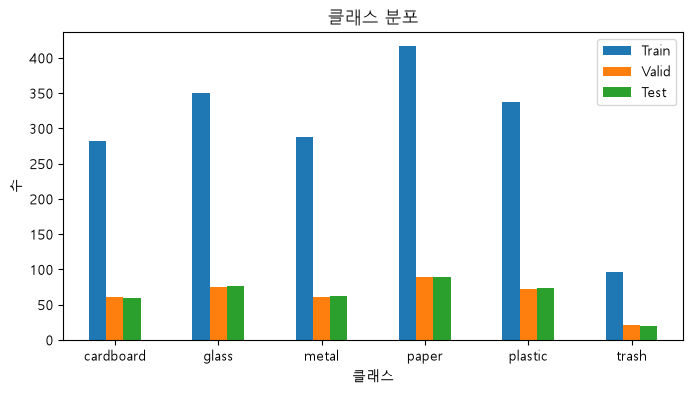

In [9]:
# 설명: 클래스 분포를 막대그래프로 시각화하여 데이터 불균형을 쉽게 확인합니다.

label_df.plot(kind='bar', figsize=(8, 4))
plt.title("클래스 분포")
plt.xlabel("클래스")
plt.ylabel("수")
plt.xticks(rotation=0)
plt.show()

### 6. DataLoader 생성하여 미니배치 학습

In [ ]:
# DataLoader worker 설정을 고려하기 위해 사용 가능한 CPU 코어 수를 확인합니다.

import os

os.cpu_count()

8

In [ ]:
# 모델 학습과 평가에 사용할 미니배치 DataLoader를 생성합니다.

# 한 번에 모델에 전달할 이미지 개수
BATCH_SIZE = 32

# 학습용 DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# 검증용 DataLoader
valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# 테스트용 DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

images, labels = next(iter(train_loader))
print(f"image_size : {images.shape} , laber_size : {labels.shape}") # (batch_size ,channel,height,width), (batch_size)


image_size : torch.Size([32, 3, 224, 224]) , laber_size : torch.Size([32])


In [81]:
# 확인: 증강 적용 전 ImageFolder가 부여한 클래스-인덱스 매핑을 확인합니다.
full_dataset_aug.class_to_idx

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}

### 7. 이미지 데이터 확인

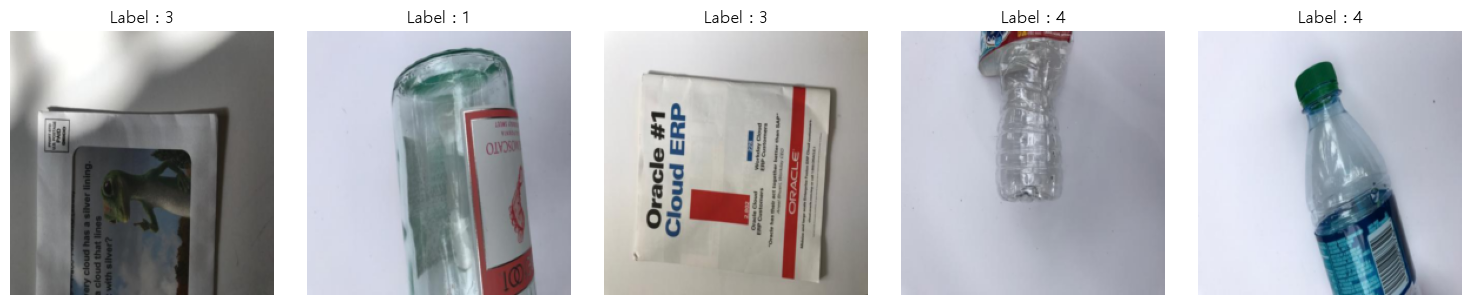

In [92]:
# 설명: 정규화된 이미지를 다시 화면 출력용 이미지로 되돌리고 샘플 이미지를 확인하는 함수를 정의합니다.

# 역전규화 함수 : 시각화해서 표현하기 위해 원래 범위에 가깝게 되돌리는 함수

def denormalize(image_tensor):
    mean = torch.tensor(
        IMAGE_MEAN,
        dtype=image_tensor.dtype,
        device=image_tensor.device
    ).view(3, 1, 1)

    std = torch.tensor(
        IMAGE_STD,
        dtype=image_tensor.dtype,
        device=image_tensor.device
    ).view(3, 1, 1)

    image_tensor = image_tensor * std + mean

# 화면 출력 시 값이 0~1 범위를 벗어나지 않도록 제한
    return image_tensor.clamp(0, 1)

# 이미지 확인 함수
def show_images(dataset, n= 10):
    plt.figure(figsize = (15,3))

    for i in range(min(n,len(dataset))):
        image, label = dataset[i]
        # 흑백 이미지는 차원이 1일 경우 삭제
        # (컬러 이미지는 삭제하지 않음. imshow[ 높이,너비,채널 ] 순으로 맞춰 사용. permute 함수로 차원 순서 변경
        image = denormalize(image).permute(1, 2, 0)

        plt.subplot(1, n, i + 1)            # subplot 위치 지정
        plt.imshow(image, cmap ='gray')     # 흑백 이미지 출력
        plt.title(f"Label : {label}")
        plt.axis('off')     # 축 제거

    plt.tight_layout()
    plt.show()
    
show_images(valid_dataset,5)

In [114]:
# 증강 적용 후에도 클래스-인덱스 매핑이 동일한지 확인합니다.
full_dataset_aug.class_to_idx

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}

In [ ]:
# 원본 이미지 파일들의 해상도, 종횡비, 용량, 밝기, 선명도(블러)를 분석하여 화질 정보를 확인합니다.

from PIL import Image
from scipy.ndimage import laplace

image_paths = list(DATA_DIR.glob("*/*.jpg")) + list(DATA_DIR.glob("*/*.jpeg")) + list(DATA_DIR.glob("*/*.png"))

quality_records = []
corrupt_files = []

for path in image_paths:
    try:
        with Image.open(path) as img:
            width, height = img.size
            file_size_kb = path.stat().st_size / 1024

            # 밝기 / 선명도 계산을 위해 흑백(그레이스케일)로 변환
            gray = np.array(img.convert("L"), dtype=np.float64)
            brightness = gray.mean()

            # 라플라시안 분산: 값이 낮을수록 흐릿(블러)한 이미지
            blur_score = laplace(gray).var()

        quality_records.append({
            "class": path.parent.name,
            "filename": path.name,
            "width": width,
            "height": height,
            "aspect_ratio": width / height,
            "file_size_kb": file_size_kb,
            "brightness": brightness,
            "blur_score": blur_score
        })
    except Exception as e:
        corrupt_files.append((path, str(e)))

quality_df = pd.DataFrame(quality_records)

print(f"분석한 이미지 수 : {len(quality_df)}")
print(f"손상되어 열 수 없는 이미지 수 : {len(corrupt_files)}")

if corrupt_files:
    for path, err in corrupt_files:
        print(f"- {path} : {err}")

quality_df.describe()


분석한 이미지 수 : 2527
손상되어 열 수 없는 이미지 수 : 0


,width,height,aspect_ratio,file_size_kb,brightness,blur_score
count,2527.0,2527.0,2.527000e+03,2527.000000,2527.000000,2527.000000
mean,512.0,384.0,1.333333e+00,16.726542,164.685113,333.466913
std,0.0,0.0,2.220886e-16,7.420650,19.997390,436.989401
min,512.0,384.0,1.333333e+00,5.472656,77.998515,2.046600
25%,512.0,384.0,1.333333e+00,11.628418,153.609304,69.369125
50%,512.0,384.0,1.333333e+00,15.024414,168.407455,172.448730
75%,512.0,384.0,1.333333e+00,19.827148,177.697617,403.308167
max,512.0,384.0,1.333333e+00,56.511719,224.416036,4119.720205


In [96]:
# 설명: 클래스별 화질 통계(해상도, 밝기, 선명도)를 요약합니다.

quality_df.groupby("class")[["width", "height", "aspect_ratio", "file_size_kb", "brightness", "blur_score"]].mean()


,width,height,aspect_ratio,file_size_kb,brightness,blur_score
class,,,,,,
cardboard,512.0,384.0,1.333333,18.429552,152.831192,229.381891
glass,512.0,384.0,1.333333,13.011202,171.444745,169.676257
metal,512.0,384.0,1.333333,17.323576,158.771757,379.025971
paper,512.0,384.0,1.333333,21.115726,165.811560,623.485671
plastic,512.0,384.0,1.333333,14.072888,170.275630,226.277760
trash,512.0,384.0,1.333333,13.822700,167.979225,221.935502


### 8. CNN 기반 이미지 분류모델

In [98]:
# 첫 번째 기준 모델로 사용할 기본 CNN 이미지 분류 모델을 정의합니다.

# GarbageCNN 재활용 이미지를 6개 클래스 중 하나로 분류하는 모델

class GarbageCNN(nn.Module):

    def __init__(self, num_classes=6, dropout_rate=0.25):
        super().__init__()

        # 이미지에서 특징을 추출하는 부분
        self.features = nn.Sequential(
            # 입력: [배치, 3, 224, 224]
            nn.Conv2d(
                in_channels=3,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(16),
            nn.SiLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(dropout_rate),
            # 출력: [배치, 16, 112, 112]
            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.SiLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(dropout_rate),
            # 출력: [배치, 32, 56, 56]
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(dropout_rate),
            # 출력: [배치, 64, 28, 28]
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.SiLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(dropout_rate)
            # 출력: [배치, 128, 14, 14]
        )

        # 추출된 특징을 바탕으로 최종 클래스를 분류하는 부분
        self.classifier = nn.Sequential(
            # [128, 14, 14] 형태를 1차원으로 변환
            nn.Flatten(),
            # 128 × 14 × 14 = 25,088개의 특징값
            nn.Linear(128 * 14 * 14, 128),
            nn.BatchNorm1d(128),
            nn.SiLU(),
            nn.Dropout(0.4),
            # 재활용 클래스 개수만큼 출력
            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):
        x = self.features(x)      # 이미지 특징 추출
        x = self.classifier(x)    # 클래스별 점수 계산

        return x                  # Softmax 적용 전 logits

model = GarbageCNN().to(device)
model

GarbageCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): SiLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
    (5): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): SiLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.25, inplace=False)
    (10): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): SiLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout2d(p=0.25, inplace=False)
    (15

### 9. 손실함수, 최적화 함수, Scheduler 설정

In [14]:
# 설명: 기본 CNN 학습에 사용할 손실함수, 옵티마이저, 스케줄러, 조기 종료를 설정합니다.

criterion = nn.CrossEntropyLoss(label_smoothing= 0.05)

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),   # 학습할 모델 파라미터
    lr=0.001,             # 학습률
    weight_decay=1e-4     # L2 규제 수치로 과적합 완화
)


# 학습률 Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",    # valid_loss가 감소하는 방향을 개선으로 판단
    factor=0.5,    # 학습률을 기존 값의 절반으로 감소
    patience=2     # 2 epoch 동안 개선되지 않으면 학습률 감소
)


### 10. EarlyStopping 클래스 정의

In [15]:
# 설명: 검증 손실이 개선되지 않을 때 학습을 멈추고 가장 좋은 모델 가중치를 복원하는 EarlyStopping 클래스를 정의합니다.

import copy


class EarlyStopping:

    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta

        self.best_loss = float("inf")
        self.counter = 0
        self.early_stop = False

        self.best_model_state = None


    def __call__(self, valid_loss, model):

        if valid_loss < self.best_loss - self.min_delta:

            self.best_loss = valid_loss
            self.counter = 0

            self.best_model_state = copy.deepcopy(
                model.state_dict()
            )

            print(
                f"Validation loss 개선: "
                f"{self.best_loss:.4f}"
            )

        else:
            self.counter += 1

            print(
                f"EarlyStopping counter: "
                f"{self.counter}/{self.patience}"
            )

            if self.counter >= self.patience:
                self.early_stop = True

        return self.early_stop


    def restore_best_weights(self, model):

        if self.best_model_state is not None:

            model.load_state_dict(
                self.best_model_state
            )

            print(
                f"최적 모델 복원 완료 | "
                f"Best Valid Loss: {self.best_loss:.4f}"
            )

### 11. 학습함수와 평가 함수 정의

In [99]:
# 학습 데이터 전체를 한 번 학습하고 평균 손실과 정확도를 계산합니다.

# 학습 데이터 전체를 한 번 학습하는 함수
def train_one_epoch(model,data_loader,criterion,optimizer,device):
    # 모델을 학습 모드로 변경
    # Dropout과 BatchNorm이 학습 방식으로 동작
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    # DataLoader에서 미니배치 단위로 데이터 가져오기
    for images, labels in tqdm(data_loader, desc = 'Train', leave= False):
        # 이미지와 라벨을 CPU 또는 GPU로 이동
        images = images.to(device)
        labels = labels.to(device)
        # 이전 미니배치에서 계산된 기울기 초기화
        optimizer.zero_grad()
        # 순전파: 모델에 이미지를 입력하여 클래스별 점수 계산
        logits = model(images)

        # 예측값과 실제 라벨을 이용하여 손실 계산
        loss = criterion(logits, labels)

        # 역전파: 손실을 기준으로 각 파라미터의 기울기 계산
        loss.backward()

        # 계산된 기울기를 이용하여 모델 가중치 수정
        optimizer.step()

        # 현재 미니배치의 손실 누적
        batch_size = images.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        # 가장 점수가 높은 클래스를 예측값으로 선택
        predictions = logits.argmax(dim=1)

        # 예측값과 정답이 같은 개수 누적
        total_correct += (
            predictions == labels
        ).sum().item()

    # 전체 데이터의 평균 손실
    avg_loss = total_loss / total_samples

    # 전체 데이터의 정확도
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc

In [100]:
# 검증 또는 테스트 데이터에서 기울기 계산 없이 손실과 정확도를 평가합니다.

# 검증 또는 테스트 데이터의 손실과 정확도를 계산하는 함수
def evaluate(model,data_loader,criterion,device):
    # 모델을 평가 모드로 변경
    # Dropout은 비활성화되고 BatchNorm은 저장된 통계 사용
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    # 평가에서는 기울기를 계산하지 않음
    with torch.no_grad():

        for images, labels in tqdm(data_loader, desc = 'Train', leave= False):

            # 이미지와 라벨을 CPU 또는 GPU로 이동
            images = images.to(device)
            labels = labels.to(device)

            # 순전파
            logits = model(images)

            # 손실 계산
            loss = criterion(logits, labels)

            batch_size = images.size(0)

            # 손실 누적
            total_loss += loss.item() * batch_size
            total_samples += batch_size

            # 예측 클래스 계산
            predictions = logits.argmax(dim=1)

            # 정답 개수 누적
            total_correct += (
                predictions == labels
            ).sum().item()

    # 전체 데이터의 평균 손실
    avg_loss = total_loss / total_samples

    # 전체 데이터의 정확도
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc

### 12. 모델 학습

In [18]:
# 설명: 첫 번째 CNN 모델을 학습하면서 epoch별 학습/검증 지표를 기록합니다.

EPOCHS = 30
early_stopping = EarlyStopping(patience=5, min_delta=0.001)

history = {
    "train_loss": [],
    "valid_loss": [],
    "train_accuracy": [],
    "valid_accuracy": [],
    "learning_rate": []
}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_accuracy = train_one_epoch(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    valid_loss, valid_accuracy = evaluate(
        model=model,
        data_loader=valid_loader,
        criterion=criterion,
        device=device
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)
    history["train_accuracy"].append(train_accuracy)
    history["valid_accuracy"].append(valid_accuracy)
    history["learning_rate"].append(current_lr)

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Valid Loss: {valid_loss:.4f} | "
        f"Train Acc: {train_accuracy * 100:.2f}% | "
        f"Valid Acc: {valid_accuracy * 100:.2f}% | "
        f"LR: {current_lr:.6f}"
    )

    scheduler.step(valid_loss)

    if early_stopping(valid_loss, model):
        print("EarlyStopping triggered: validation loss did not improve.")
        break

early_stopping.restore_best_weights(model)


Train:   0%|          | 0/56 [00:00<?, ?it/s]

Train:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch [01/30] | Train Loss: 1.5639 | Valid Loss: 1.4004 | Train Acc: 38.63% | Valid Acc: 53.03% | LR: 0.001000
Validation loss 개선: 1.4004


Train:   0%|          | 0/56 [00:00<?, ?it/s]

Train:   0%|          | 0/12 [00:00<?, ?it/s]

...

Train:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch [26/30] | Train Loss: 0.7483 | Valid Loss: 0.9466 | Train Acc: 79.64% | Valid Acc: 70.45% | LR: 0.000500
EarlyStopping counter: 4/5


Train:   0%|          | 0/56 [00:00<?, ?it/s]

Train:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch [27/30] | Train Loss: 0.7051 | Valid Loss: 0.9520 | Train Acc: 81.96% | Valid Acc: 70.45% | LR: 0.000500
EarlyStopping counter: 5/5
EarlyStopping triggered: validation loss did not improve.
최적 모델 복원 완료 | Best Valid Loss: 0.9412


In [94]:
# 설명: 첫 번째 CNN 학습 기록을 DataFrame으로 변환해 표 형태로 확인합니다.

history_df = pd.DataFrame(history)
history_df.tail()

,train_loss,valid_loss,train_accuracy,valid_accuracy,learning_rate
22,0.804684,0.982421,0.772059,0.672823,0.0010
23,0.766139,0.976041,0.787330,0.672823,0.0010
24,0.763564,0.963916,0.787330,0.704485,0.0010
25,0.748292,0.946567,0.796380,0.704485,0.0005
26,0.705070,0.951957,0.819570,0.704485,0.0005


학습은 계속 좋아지지만 검증 성능은 더 이상 좋아지지 않는 과적합 상태이다.

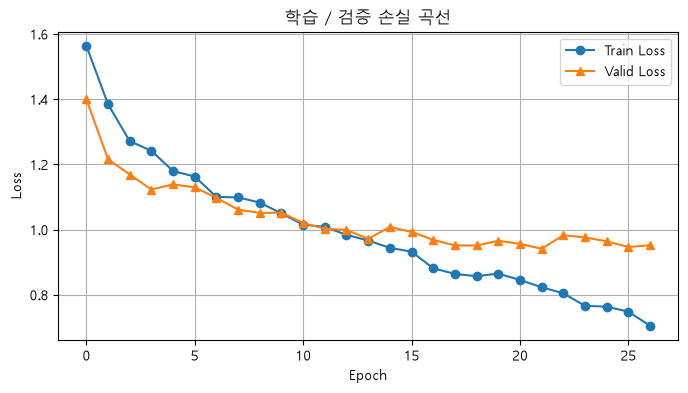

In [101]:
# 설명: 첫 번째 CNN의 학습 손실과 검증 손실 변화를 그래프로 확인합니다.

# Train and Validation Loss

plt.figure(figsize = (8,4))
plt.plot( history_df['train_loss'], marker = 'o', label = 'Train Loss')
plt.plot( history_df['valid_loss'], marker = '^', label = 'Valid Loss')
plt.title('학습 / 검증 손실 곡선')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

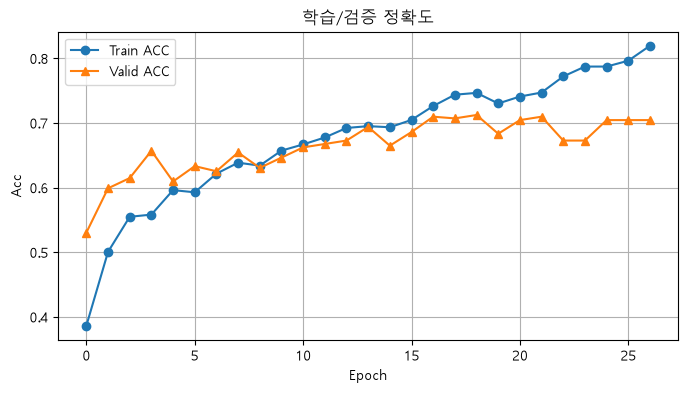

In [102]:
# 설명: 첫 번째 CNN의 학습 정확도와 검증 정확도 변화를 그래프로 확인합니다.

# Train and Validation 정확도 곡선

plt.figure(figsize = (8,4))
plt.plot(history_df['train_accuracy'], marker = 'o', label = 'Train ACC')
plt.plot(history_df['valid_accuracy'], marker = '^', label = 'Valid ACC')
plt.title('학습/검증 정확도')
plt.xlabel('Epoch')
plt.ylabel('Acc')
plt.legend()
plt.grid(True)
plt.show()

### 13. 고도화

- 데이터 증강 강화

In [103]:
# 개선된 CNN 실험을 위해 더 강한 이미지 증강 전처리를 정의합니다.

IMAGE_MEAN = (0.5, 0.5, 0.5)
IMAGE_STD = (0.5, 0.5, 0.5)

IMAGE_SIZE = 224


# 학습 데이터 전처리
train_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # 좌우 반전
    transforms.RandomHorizontalFlip(p=0.5),

    # 회전 범위 조금 확대
    transforms.RandomRotation(15),

    # 밝기, 대비, 채도 변화
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGE_MEAN,
        IMAGE_STD
    )
])


# 검증 / 테스트 데이터 전처리
eval_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGE_MEAN,
        IMAGE_STD
    )
])

- 데이터셋 객체 다시 생성

In [104]:
# 강화된 증강 전처리를 적용한 ImageFolder 데이터셋을 다시 생성합니다.

full_dataset_aug = datasets.ImageFolder(
    root=DATA_DIR,
    transform=train_transform
)

full_dataset_eval = datasets.ImageFolder(
    root=DATA_DIR,
    transform=eval_transform
)

In [24]:
# 설명: 기존 train, valid, test 인덱스를 새 데이터셋에 동일하게 적용합니다.

train_dataset = Subset(
    full_dataset_aug,
    train_indices
)

valid_dataset = Subset(
    full_dataset_eval,
    valid_indices
)

test_dataset = Subset(
    full_dataset_eval,
    test_indices
)

- 데이터 로더 재 생성

In [25]:
# 설명: 변경된 데이터셋을 바탕으로 DataLoader를 다시 생성합니다.

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [105]:
# 더 깊은 구조와 Dropout을 포함한 두 번째 CNN 모델을 정의합니다.

class GarbageCNNV2(nn.Module):

    def __init__(self, num_classes=6, dropout_rate=0.2):
        super().__init__()

        # 이미지 특징 추출
        self.features = nn.Sequential(

            # 3 × 224 × 224
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.SiLU(),
            nn.MaxPool2d(kernel_size=2),
            # 16 × 112 × 112


            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.SiLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(dropout_rate),
            # 32 × 56 × 56


            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(dropout_rate),
            # 64 × 28 × 28


            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.SiLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(dropout_rate),
            # 128 × 14 × 14


            # 각 특징맵의 평균값 하나만 남김
            nn.AdaptiveAvgPool2d((1, 1))
            # 128 × 1 × 1
        )

        # 최종 분류기
        self.classifier = nn.Sequential(

            nn.Flatten(),
            # 128 × 1 × 1 → 128

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.SiLU(),
            nn.Dropout(0.4),

            nn.Linear(64, num_classes)
        )


    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

- 현재 trash 이미지가 다른 클래스보다 적기 때문에 클래스 불균형 가중치 적용

In [106]:
# 감지된 클래스 개수에 맞춰 개선된 CNN 모델을 생성합니다.

NUM_CLASSES = len(full_dataset_aug.classes)

model_v2 = GarbageCNNV2(
    num_classes=NUM_CLASSES,
    dropout_rate=0.2
).to(device)

In [107]:
# 클래스 불균형을 줄이기 위해 학습 데이터 기준 클래스 가중치를 계산합니다.

# 학습 데이터의 라벨만 가져오기
all_targets = np.array(full_dataset_aug.targets)

train_labels = all_targets[
    np.array(train_indices)
]

# 클래스별 학습 이미지 개수
class_counts = np.bincount(
    train_labels,
    minlength=NUM_CLASSES
)

# 데이터가 적은 클래스일수록 높은 가중치 부여
class_weights = (
    len(train_labels)
    / (NUM_CLASSES * class_counts)
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)


for class_name, count, weight in zip(
    full_dataset_aug.classes,
    class_counts,
    class_weights.cpu().numpy()
):
    print(
        f"{class_name:10s} | "
        f"데이터 수: {count:4d} | "
        f"가중치: {weight:.4f}"
    )

cardboard  | 데이터 수:  282 | 가중치: 1.0449
glass      | 데이터 수:  350 | 가중치: 0.8419
metal      | 데이터 수:  287 | 가중치: 1.0267
paper      | 데이터 수:  416 | 가중치: 0.7083
plastic    | 데이터 수:  337 | 가중치: 0.8744
trash      | 데이터 수:   96 | 가중치: 3.0694


In [ ]:
# 개선된 CNN 학습에 사용할 손실함수, 옵티마이저, 스케줄러, 조기 종료를 설정합니다.

criterion_v2 = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.05
)

optimizer_v2 = optim.AdamW(
    model_v2.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

scheduler_v2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v2,
    mode="min",
    factor=0.5,
    patience=2
)

early_stopping_v2 = EarlyStopping(
    patience=6,
    min_delta=0.001
)

In [ ]:
# 학습 전 개선된 CNN의 초기 검증 성능을 확인합니다.

initial_valid_loss_v2, initial_valid_accuracy_v2 = evaluate(
    model=model_v2,
    data_loader=valid_loader,
    criterion=criterion_v2,
    device=device
)

print(
    f"Initial V2 Valid Loss: {initial_valid_loss_v2:.4f} | "
    f"Initial V2 Valid Acc: {initial_valid_accuracy_v2 * 100:.2f}%"
)


Train:   0%|          | 0/12 [00:00<?, ?it/s]

Initial V2 Valid Loss: 1.8161 | Initial V2 Valid Acc: 5.54%


In [ ]:
# 개선된 CNN을 학습하고 epoch별 지표를 기록합니다.

EPOCHS = 40

history_v2 = {
    "train_loss": [],
    "valid_loss": [],
    "train_accuracy": [],
    "valid_accuracy": [],
    "learning_rate": []
}

for epoch in range(1, EPOCHS + 1):

    train_loss, train_accuracy = train_one_epoch(
        model=model_v2,
        data_loader=train_loader,
        criterion=criterion_v2,
        optimizer=optimizer_v2,
        device=device
    )

    valid_loss, valid_accuracy = evaluate(
        model=model_v2,
        data_loader=valid_loader,
        criterion=criterion_v2,
        device=device
    )

    current_lr = optimizer_v2.param_groups[0]["lr"]

    history_v2["train_loss"].append(train_loss)
    history_v2["valid_loss"].append(valid_loss)
    history_v2["train_accuracy"].append(train_accuracy)
    history_v2["valid_accuracy"].append(valid_accuracy)
    history_v2["learning_rate"].append(current_lr)

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Valid Loss: {valid_loss:.4f} | "
        f"Train Acc: {train_accuracy * 100:.2f}% | "
        f"Valid Acc: {valid_accuracy * 100:.2f}% | "
        f"LR: {current_lr:.6f}"
    )

    scheduler_v2.step(valid_loss)

    if early_stopping_v2(valid_loss, model_v2):
        print("EarlyStopping triggered: validation loss did not improve.")
        break

early_stopping_v2.restore_best_weights(model_v2)


Train:   0%|          | 0/56 [00:00<?, ?it/s]

Train:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch [01/40] | Train Loss: 1.6901 | Valid Loss: 1.5613 | Train Acc: 29.52% | Valid Acc: 36.15% | LR: 0.000500
Validation loss 개선: 1.5613


Train:   0%|          | 0/56 [00:00<?, ?it/s]

Train:   0%|          | 0/12 [00:00<?, ?it/s]

...

Train:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch [38/40] | Train Loss: 1.2529 | Valid Loss: 1.1384 | Train Acc: 55.94% | Valid Acc: 57.52% | LR: 0.000063
EarlyStopping counter: 5/6


Train:   0%|          | 0/56 [00:00<?, ?it/s]

Train:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch [39/40] | Train Loss: 1.2732 | Valid Loss: 1.1272 | Train Acc: 54.47% | Valid Acc: 57.52% | LR: 0.000063
EarlyStopping counter: 6/6
EarlyStopping triggered: validation loss did not improve.
최적 모델 복원 완료 | Best Valid Loss: 1.1255


In [ ]:
# 첫 번째 CNN과 개선된 CNN의 검증 성능을 비교합니다.

result_v1 = {
    "model": "GarbageCNN V1",
    "best_valid_loss": min(history["valid_loss"]),
    "best_valid_accuracy": max(history["valid_accuracy"])
}

result_v2 = {
    "model": "GarbageCNN V2",
    "best_valid_loss": min(history_v2["valid_loss"]),
    "best_valid_accuracy": max(history_v2["valid_accuracy"])
}

comparison_df = pd.DataFrame([
    result_v1,
    result_v2
])

comparison_df

,model,best_valid_loss,best_valid_accuracy
0,GarbageCNN V1,0.941246,0.712401
1,GarbageCNN V2,1.125457,0.593668


In [ ]:
# 개선된 CNN의 테스트 데이터 예측 결과를 수집합니다.

from sklearn.metrics import classification_report

model_v2.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        logits = model_v2(images)
        predictions = logits.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

In [34]:
# 설명: 개선된 CNN의 테스트 분류 리포트를 출력합니다.

print(
    classification_report(
        y_true,
        y_pred,
        target_names=full_dataset_aug.classes,
        digits=4
    )
)

              precision    recall  f1-score   support

   cardboard     0.8364    0.7667    0.8000        60
       glass     0.6222    0.3684    0.4628        76
       metal     0.6667    0.3226    0.4348        62
       paper     0.7065    0.7303    0.7182        89
     plastic     0.5974    0.6301    0.6133        73
       trash     0.2346    0.9500    0.3762        20

    accuracy                         0.5895       380
   macro avg     0.6106    0.6280    0.5676       380
weighted avg     0.6579    0.5895    0.5957       380



### 혼동행렬 매트릭스

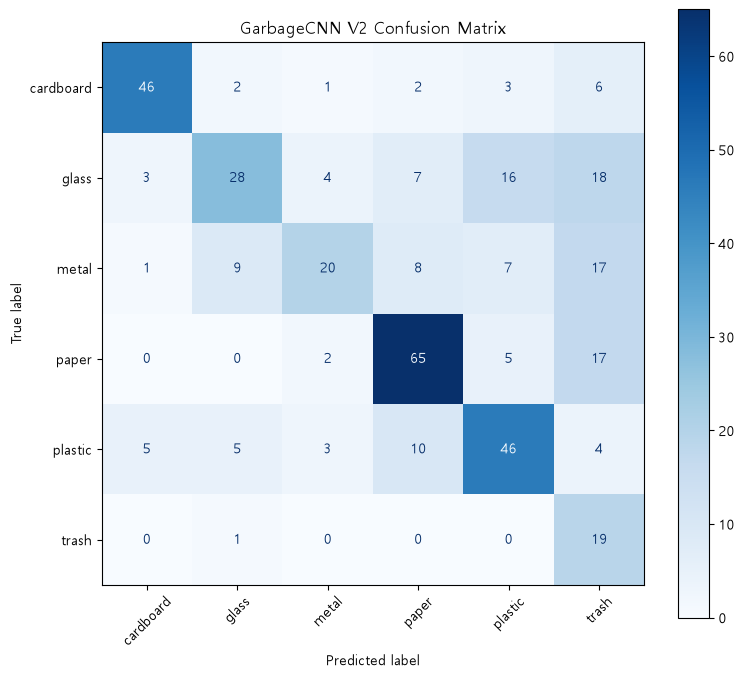

In [35]:
# 설명: 개선된 CNN의 테스트 혼동행렬을 생성하고 시각화합니다.

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=full_dataset_aug.classes
)

fig, ax = plt.subplots(figsize=(8, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("GarbageCNN V2 Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
# 설명: 특정 실제 클래스가 특정 클래스로 예측된 오분류 이미지를 보여주는 함수를 정의합니다.

def show_misclassified_by_class(
    dataset,
    y_true,
    y_pred,
    true_class,
    pred_class,
    class_names,
    n=10
):
    indices = [
        i for i, (true_label, pred_label)
        in enumerate(zip(y_true, y_pred))
        if true_label == true_class
        and pred_label == pred_class
    ]

    plt.figure(figsize=(15, 6))

    for plot_idx, data_idx in enumerate(indices[:n]):
        image, label = dataset[data_idx]

        image = denormalize(image)
        image = image.permute(1, 2, 0)

        plt.subplot(2, 5, plot_idx + 1)
        plt.imshow(image)
        plt.title(
            f"T: {class_names[true_class]}\n"
            f"P: {class_names[pred_class]}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

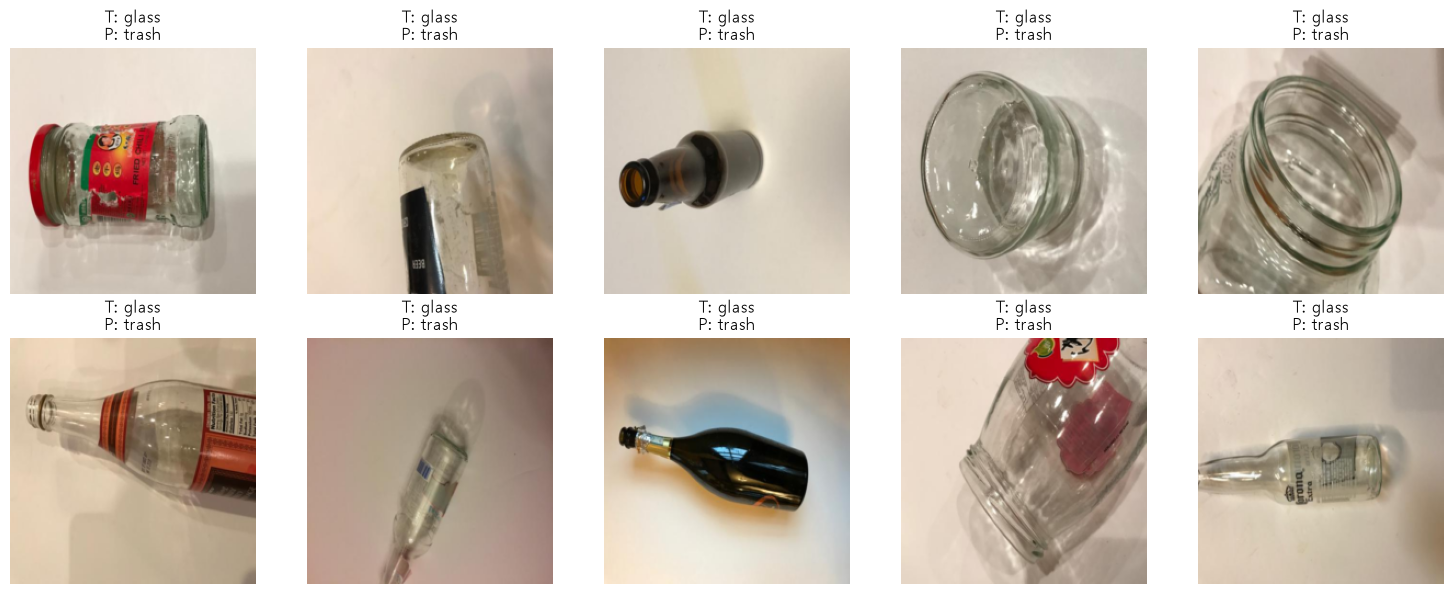

In [113]:
# plastic 이미지를 metal로 잘못 예측한 사례를 확인합니다.

class_names = full_dataset_aug.classes

plastic_index = class_names.index("glass")
metal_index = class_names.index("trash")

show_misclassified_by_class(
    dataset=test_dataset,
    y_true=y_true,
    y_pred=y_pred,
    true_class=plastic_index,
    pred_class=metal_index,
    class_names=class_names,
    n=10
)

- ResNet18 전이학습 적용

In [38]:
# 설명: ResNet18 전이학습에 맞는 ImageNet 정규화와 전처리 방법을 정의합니다.

IMAGE_SIZE = 224

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


train_transform_resnet = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])


eval_transform_resnet = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])

- 데이터셋 다시 생성

In [ ]:
# ResNet용 학습 데이터셋과 평가 데이터셋을 생성합니다.

full_dataset_resnet_train = datasets.ImageFolder(
    root=DATA_DIR,
    transform=train_transform_resnet
)

full_dataset_resnet_eval = datasets.ImageFolder(
    root=DATA_DIR,
    transform=eval_transform_resnet
)

train_dataset_resnet = Subset(
    full_dataset_resnet_train,
    train_indices
)

valid_dataset_resnet = Subset(
    full_dataset_resnet_eval,
    valid_indices
)

test_dataset_resnet = Subset(
    full_dataset_resnet_eval,
    test_indices
)

In [ ]:
# ResNet 학습, 검증, 테스트에 사용할 DataLoader를 생성합니다.

BATCH_SIZE = 32

train_loader_resnet = DataLoader(
    train_dataset_resnet,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_loader_resnet = DataLoader(
    valid_dataset_resnet,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader_resnet = DataLoader(
    test_dataset_resnet,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
# 사전학습된 ResNet18 모델과 기본 ImageNet 가중치를 불러옵니다.

from torchvision.models import resnet18, ResNet18_Weights

In [ ]:
# 사전학습된 ResNet18을 불러오고 마지막 분류층을 쓰레기 클래스 수에 맞게 교체합니다.

NUM_CLASSES = len(full_dataset_resnet_train.classes)

weights = ResNet18_Weights.DEFAULT

resnet_model = resnet18(
    weights=weights
)

in_features = resnet_model.fc.in_features

for parameter in resnet_model.parameters():
    parameter.requires_grad = False

resnet_model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, NUM_CLASSES)
)

resnet_model = resnet_model.to(device)

resnet_model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [ ]:
# 실제로 학습되는 ResNet 파라미터를 출력해 설정이 맞는지 확인합니다.

for name, parameter in resnet_model.named_parameters():

    if parameter.requires_grad:
        print(name, parameter.shape)

fc.1.weight torch.Size([6, 512])
fc.1.bias torch.Size([6])


In [ ]:
# ResNet 학습 전에 입력과 출력 텐서 크기가 정상인지 확인합니다.

images, labels = next(iter(train_loader_resnet))

images = images.to(device)

with torch.no_grad():
    outputs = resnet_model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)


Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 6])


In [ ]:
# ResNet18을 한 epoch 학습하는 함수를 정의합니다.

def train_one_epoch_resnet(
    model,
    data_loader,
    criterion,
    optimizer,
    device
):
    model.eval()
    model.fc.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in tqdm(
        data_loader,
        desc="Train",
        leave=False
    ):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        predictions = logits.argmax(dim=1)
        total_correct += (
            predictions == labels
        ).sum().item()

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return average_loss, accuracy

In [ ]:
# ResNet18 전이학습에 사용할 손실함수, 옵티마이저, 스케줄러, 조기 종료를 설정합니다.

criterion_resnet = nn.CrossEntropyLoss(
    label_smoothing=0.05
)

optimizer_resnet = optim.AdamW(
    resnet_model.fc.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler_resnet = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_resnet,
    mode="min",
    factor=0.5,
    patience=2
)

early_stopping_resnet = EarlyStopping(
    patience=5,
    min_delta=0.001
)

In [62]:
# 설명: ResNet18을 학습하고 epoch별 학습/검증 지표를 저장합니다.

EPOCHS = 20

history_resnet = {
    "epoch": [],
    "train_loss": [],
    "valid_loss": [],
    "train_accuracy": [],
    "valid_accuracy": [],
    "learning_rate": []
}

for epoch in range(1, EPOCHS + 1):

    train_loss, train_accuracy = train_one_epoch_resnet(
        model=resnet_model,
        data_loader=train_loader_resnet,
        criterion=criterion_resnet,
        optimizer=optimizer_resnet,
        device=device
    )

    valid_loss, valid_accuracy = evaluate(
        model=resnet_model,
        data_loader=valid_loader_resnet,
        criterion=criterion_resnet,
        device=device
    )

    current_lr = optimizer_resnet.param_groups[0]["lr"]

    history_resnet["epoch"].append(epoch)
    history_resnet["train_loss"].append(train_loss)
    history_resnet["valid_loss"].append(valid_loss)
    history_resnet["train_accuracy"].append(train_accuracy)
    history_resnet["valid_accuracy"].append(valid_accuracy)
    history_resnet["learning_rate"].append(current_lr)

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Valid Loss: {valid_loss:.4f} | "
        f"Train Acc: {train_accuracy * 100:.2f}% | "
        f"Valid Acc: {valid_accuracy * 100:.2f}% | "
        f"LR: {current_lr:.6f}"
    )

    scheduler_resnet.step(valid_loss)

    if early_stopping_resnet(
        valid_loss,
        resnet_model
    ):
        print("EarlyStopping triggered: validation loss did not improve.")
        break

early_stopping_resnet.restore_best_weights(
    resnet_model
)


Train:   0%|          | 0/56 [00:00<?, ?it/s]

Train:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch [01/20] | Train Loss: 1.4558 | Valid Loss: 1.1527 | Train Acc: 45.31% | Valid Acc: 60.16% | LR: 0.001000
Validation loss 개선: 1.1527


Train:   0%|          | 0/56 [00:00<?, ?it/s]

Train:   0%|          | 0/12 [00:00<?, ?it/s]

...

Train:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch [19/20] | Train Loss: 0.8810 | Valid Loss: 0.7778 | Train Acc: 73.42% | Valid Acc: 79.16% | LR: 0.001000
EarlyStopping counter: 2/5


Train:   0%|          | 0/56 [00:00<?, ?it/s]

Train:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch [20/20] | Train Loss: 0.8893 | Valid Loss: 0.8004 | Train Acc: 72.23% | Valid Acc: 77.31% | LR: 0.001000
EarlyStopping counter: 3/5
최적 모델 복원 완료 | Best Valid Loss: 0.7738


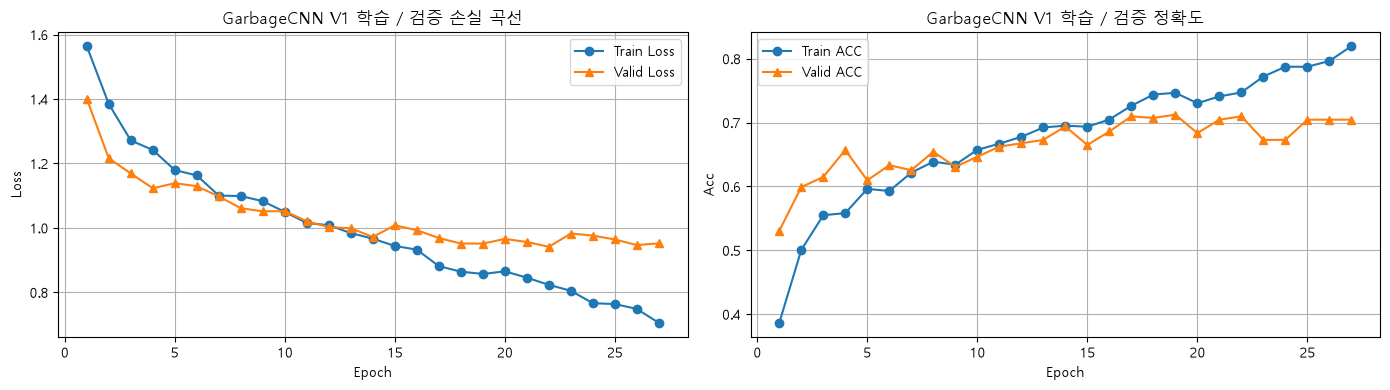

In [63]:
# 설명: 첫 번째 CNN의 손실과 정확도 그래프를 한 화면에서 확인합니다.

history_df = pd.DataFrame(history)

epoch_axis = history_df.index + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epoch_axis, history_df['train_loss'], marker='o', label='Train Loss')
axes[0].plot(epoch_axis, history_df['valid_loss'], marker='^', label='Valid Loss')
axes[0].set_title('GarbageCNN V1 학습 / 검증 손실 곡선')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epoch_axis, history_df['train_accuracy'], marker='o', label='Train ACC')
axes[1].plot(epoch_axis, history_df['valid_accuracy'], marker='^', label='Valid ACC')
axes[1].set_title('GarbageCNN V1 학습 / 검증 정확도')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Acc')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

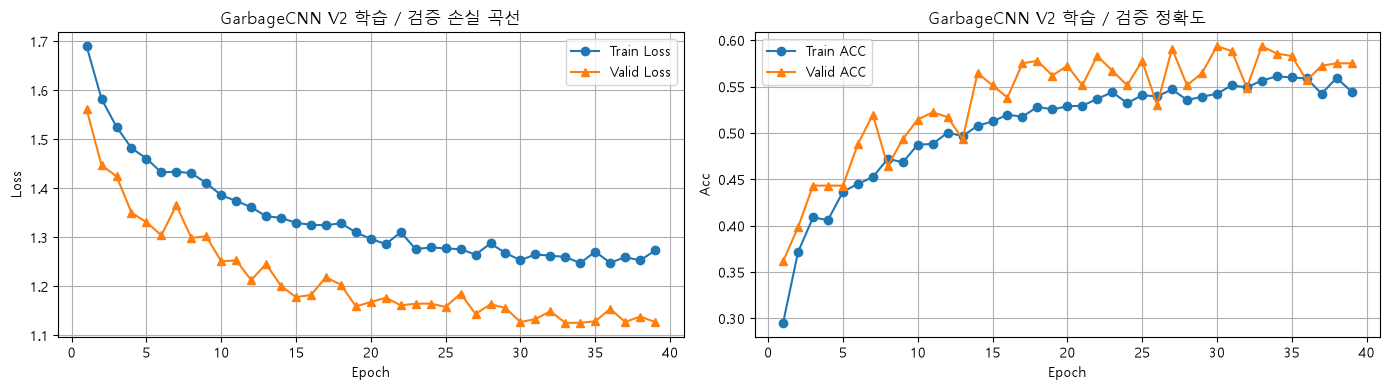

In [64]:
# 설명: 개선된 CNN의 손실과 정확도 그래프를 한 화면에서 확인합니다.

history_df2 = pd.DataFrame(history_v2)

epoch_axis = history_df2.index + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epoch_axis, history_df2['train_loss'], marker='o', label='Train Loss')
axes[0].plot(epoch_axis, history_df2['valid_loss'], marker='^', label='Valid Loss')
axes[0].set_title('GarbageCNN V2 학습 / 검증 손실 곡선')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epoch_axis, history_df2['train_accuracy'], marker='o', label='Train ACC')
axes[1].plot(epoch_axis, history_df2['valid_accuracy'], marker='^', label='Valid ACC')
axes[1].set_title('GarbageCNN V2 학습 / 검증 정확도')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Acc')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [87]:
history_df2.tail()

,train_loss,valid_loss,train_accuracy,valid_accuracy,learning_rate
34,1.270942,1.128720,0.559955,0.583113,0.000125
35,1.248096,1.154051,0.558824,0.556728,0.000125
36,1.259702,1.127264,0.542421,0.572559,0.000063
37,1.252915,1.138374,0.559389,0.575198,0.000063
38,1.273223,1.127179,0.544683,0.575198,0.000063


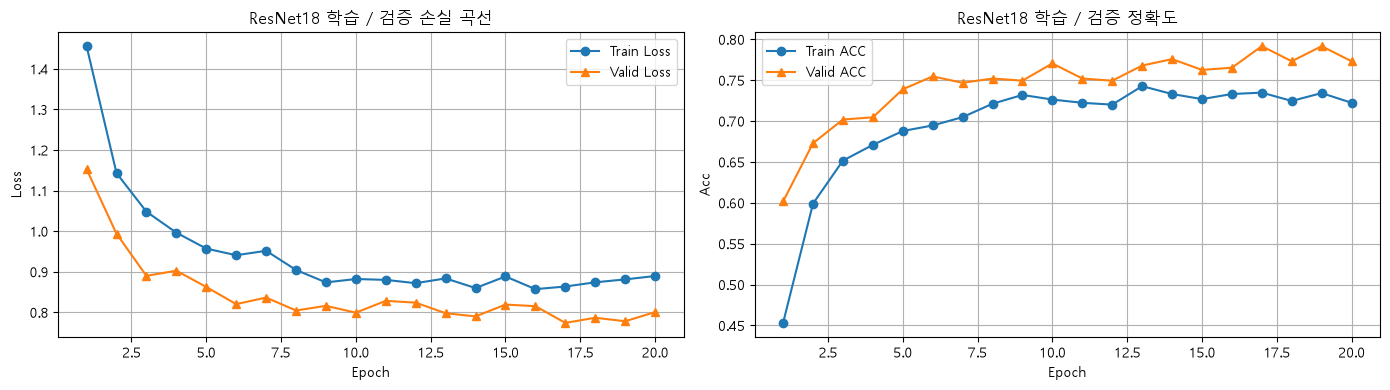

In [66]:
# 설명: ResNet18의 손실과 정확도 그래프를 한 화면에서 확인합니다.

history_df_res = pd.DataFrame(history_resnet)

epoch_axis = history_df_res['epoch'] if 'epoch' in history_df_res.columns else history_df_res.index + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epoch_axis, history_df_res['train_loss'], marker='o', label='Train Loss')
axes[0].plot(epoch_axis, history_df_res['valid_loss'], marker='^', label='Valid Loss')
axes[0].set_title('ResNet18 학습 / 검증 손실 곡선')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epoch_axis, history_df_res['train_accuracy'], marker='o', label='Train ACC')
axes[1].plot(epoch_axis, history_df_res['valid_accuracy'], marker='^', label='Valid ACC')
axes[1].set_title('ResNet18 학습 / 검증 정확도')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Acc')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [88]:
history_df_res.tail()

,epoch,train_loss,valid_loss,train_accuracy,valid_accuracy,learning_rate
15,16,0.857001,0.815018,0.733032,0.765172,0.001
16,17,0.863403,0.773784,0.734729,0.791557,0.001
17,18,0.873810,0.786431,0.724548,0.773087,0.001
18,19,0.880980,0.777839,0.734163,0.791557,0.001
19,20,0.889346,0.800350,0.722285,0.773087,0.001


### 14. Test 데이터 최종평가


Train:   0%|          | 0/12 [00:00<?, ?it/s]

ResNet18 Test Loss: 0.7268
ResNet18 Test Accuracy: 81.58%


Get Predictions:   0%|          | 0/12 [00:00<?, ?it/s]

              precision    recall  f1-score   support

   cardboard     0.9245    0.8167    0.8673        60
       glass     0.7333    0.8684    0.7952        76
       metal     0.7612    0.8226    0.7907        62
       paper     0.8370    0.8652    0.8508        89
     plastic     0.8636    0.7808    0.8201        73
       trash     0.8333    0.5000    0.6250        20

    accuracy                         0.8158       380
   macro avg     0.8255    0.7756    0.7915       380
weighted avg     0.8226    0.8158    0.8147       380



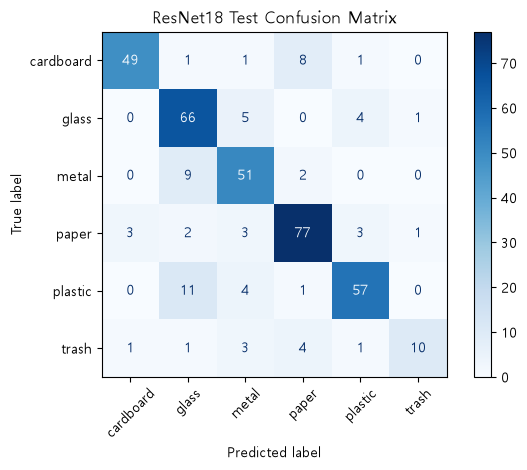

In [89]:
# 설명: 최종 선택 모델인 ResNet18을 테스트 데이터로 평가하고 예측 결과를 수집합니다.

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 최종 모델은 검증 데이터 기준 EarlyStopping으로 복원된 ResNet18 사용
test_loss_resnet, test_accuracy_resnet = evaluate(
    model=resnet_model,
    data_loader=test_loader_resnet,
    criterion=criterion_resnet,
    device=device
)

print(f"ResNet18 Test Loss: {test_loss_resnet:.4f}")
print(f"ResNet18 Test Accuracy: {test_accuracy_resnet * 100:.2f}%")

resnet_model.eval()

class_names_resnet = full_dataset_resnet_train.classes
y_true_resnet = []
y_pred_resnet = []
y_prob_resnet = []

with torch.no_grad():
    for images, labels in tqdm(
        test_loader_resnet,
        desc="Get Predictions",
        leave=False
    ):
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet_model(images)
        probabilities = torch.softmax(outputs, dim=1)
        predictions = probabilities.argmax(dim=1)

        y_true_resnet.extend(labels.cpu().numpy())
        y_pred_resnet.extend(predictions.cpu().numpy())
        y_prob_resnet.extend(probabilities.cpu().numpy())

y_true_resnet = np.array(y_true_resnet)
y_pred_resnet = np.array(y_pred_resnet)
y_prob_resnet = np.array(y_prob_resnet)

print(
    classification_report(
        y_true_resnet,
        y_pred_resnet,
        target_names=class_names_resnet,
        digits=4
    )
)

cm_resnet = confusion_matrix(
    y_true_resnet,
    y_pred_resnet
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_resnet,
    display_labels=class_names_resnet
).plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("ResNet18 Test Confusion Matrix")
plt.tight_layout()
plt.show()


### 17. 예측 결과 이미지 확인


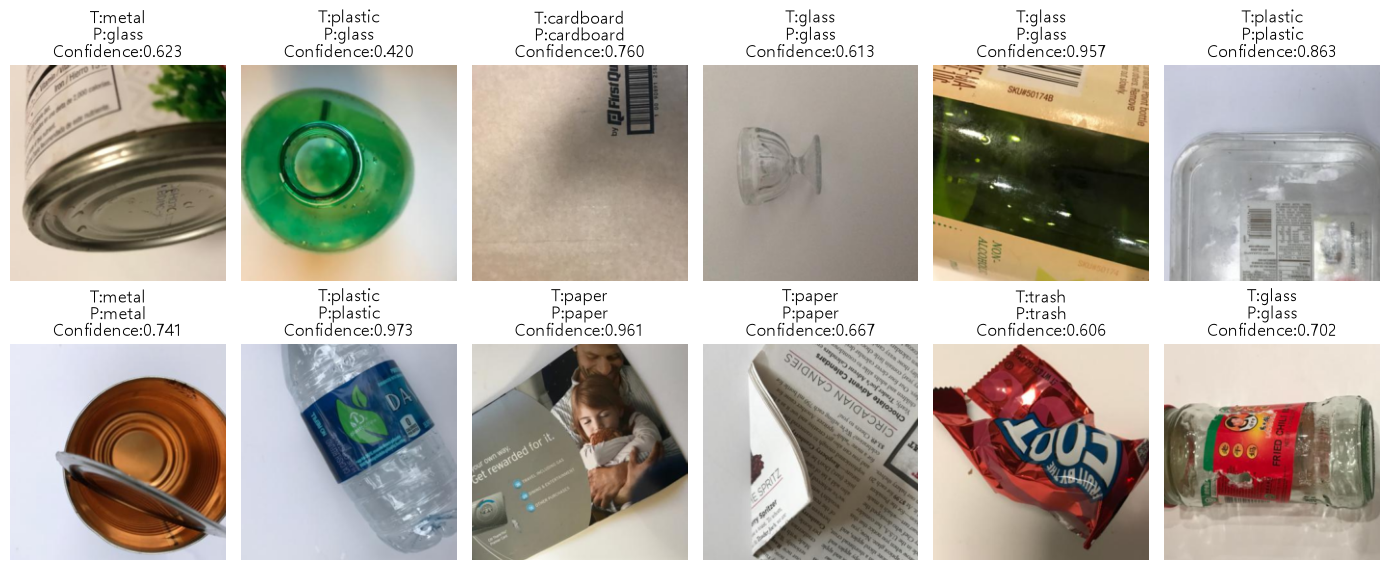

In [116]:
# 테스트 이미지와 함께 실제 라벨, 예측 라벨, 예측 확률을 시각화합니다.

# 테스트 이미지와 예측 결과를 출력하는 함수
def denormalize_resnet(image_tensor):
    mean = torch.tensor(
        IMAGENET_MEAN,
        dtype=image_tensor.dtype,
        device=image_tensor.device
    ).view(3, 1, 1)

    std = torch.tensor(
        IMAGENET_STD,
        dtype=image_tensor.dtype,
        device=image_tensor.device
    ).view(3, 1, 1)

    image_tensor = image_tensor * std + mean

    return image_tensor.clamp(0, 1)


def show_predictions_garbage(dataset, y_pred, y_prob, class_names, n=12):
    n = min(n, len(dataset))

    plt.figure(figsize=(14, 6))

    for i in range(n):
        image, label = dataset[i]
        image_for_plot = denormalize_resnet(image).permute(1, 2, 0).cpu().numpy()

        pred_label = y_pred[i]
        confidence = y_prob[i, pred_label]

        plt.subplot(2, 6, i + 1)
        plt.imshow(image_for_plot)
        plt.title(
            f"T:{class_names[label]}\n"
            f"P:{class_names[pred_label]}\n"
            f"Confidence:{confidence:.3f}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_predictions_garbage(
    test_dataset_resnet,
    y_pred_resnet,
    y_prob_resnet,
    class_names_resnet
)


### 18. 오분류 이미지 확인


In [73]:
# 설명: ResNet18이 틀리게 예측한 테스트 이미지의 인덱스를 찾습니다.

wrong_indices = np.where(y_true_resnet != y_pred_resnet)[0]
len(wrong_indices)


70

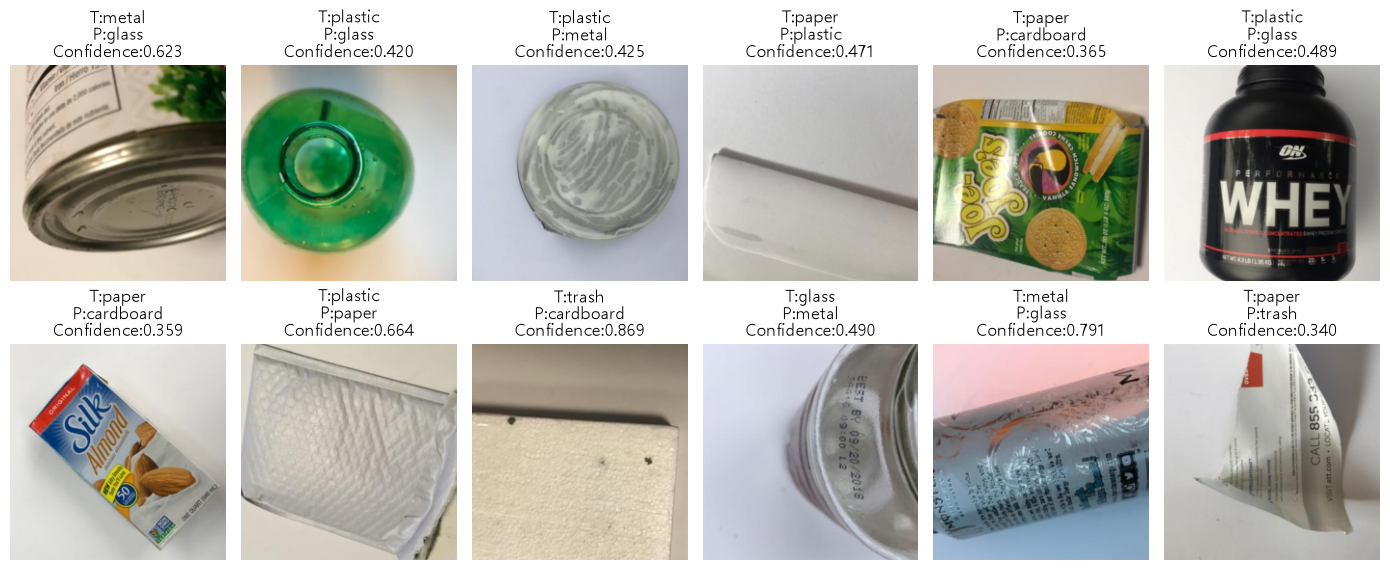

In [74]:
# 설명: 오분류 이미지를 직접 확인하여 모델이 어떤 유형에서 실수하는지 분석합니다.

def show_misclassified_garbage(dataset, wrong_indices, y_pred, y_prob, class_names, n=12):
    if len(wrong_indices) == 0:
        print("No misclassified images")
        return

    n = min(n, len(wrong_indices))

    plt.figure(figsize=(14, 6))

    for plot_idx in range(n):
        data_idx = wrong_indices[plot_idx]
        image, label = dataset[data_idx]
        image_for_plot = denormalize_resnet(image).permute(1, 2, 0).cpu().numpy()

        pred_label = y_pred[data_idx]
        confidence = y_prob[data_idx, pred_label]

        plt.subplot(2, 6, plot_idx + 1)
        plt.imshow(image_for_plot)
        plt.title(
            f"T:{class_names[label]}\n"
            f"P:{class_names[pred_label]}\n"
            f"Confidence:{confidence:.3f}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_misclassified_garbage(
    test_dataset_resnet,
    wrong_indices,
    y_pred_resnet,
    y_prob_resnet,
    class_names_resnet
)


### 19. 단일 이미지 예측 함수


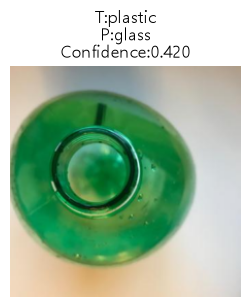

('glass', 0.4204670190811157)

In [80]:
# 설명: 테스트 이미지 하나를 선택해 예측 결과와 확률을 시각화합니다.

def predict_one_garbage_image(model, dataset, index, device, class_names):
    model.eval()

    image, true_label = dataset[index]
    input_image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_image)
        probabilities = torch.softmax(outputs, dim=1)
        pred_label = probabilities.argmax(dim=1).item()
        confidence = probabilities[0, pred_label].item()

    image_for_plot = denormalize_resnet(image).permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(3, 3))
    plt.imshow(image_for_plot)
    plt.title(
        f"T:{class_names[true_label]}\n"
        f"P:{class_names[pred_label]}\n"
        f"Confidence:{confidence:.3f}"
    )
    plt.axis("off")
    plt.show()

    return class_names[pred_label], confidence


predict_one_garbage_image(
    resnet_model,
    test_dataset_resnet,
    index=1,
    device=device,
    class_names=class_names_resnet
)


### 주요 하이퍼파라미터

|항목	|GarbageCNN V1	|GarbageCNN V2	|ResNet18|
|---|---|---|---|
|이미지 크기	|224 × 224|	224 × 224	|224 × 224|
|Batch Size|	32	|32	|32|
|최대 Epoch|	30	|40	|20|
|Learning Rate	|0.001	|0.0005|	0.001|
|Weight Decay|	1e-4	|1e-4|	1e-4|
|Label Smoothing	|0.05	|0.05	|0.05|
|Dropout|	0.25 / 0.4	|0.2 / 0.4	|0.3|
|EarlyStopping Patience|	5|	6	|5|
|Scheduler Factor|	0.5	|0.5	|0.5|
|Scheduler Patience	|2	|2	|""|

직접 설계한 GarbageCNN과 개선된 CNN을 학습한 뒤 ResNet18 전이학습 모델과 성능을 비교하였다.

GarbageCNN V1의 최고 검증 정확도는 71%, GarbageCNN V2의 최고 검증 정확도는 59%였다.

ResNet18은 최고 검증 정확도 79%를 기록하였고, 최종 테스트 데이터에서 81.58%의 정확도와 79.15%의 Macro F1-score를 기록하였다.

따라서 본 프로젝트에서는 ResNet18 전이학습 모델을 최종 모델로 선정하였다.

사전 학습된 모델이 일반적인 이미지의 형태, 경계, 색상 및 질감 특징을 이미 학습하고 있었기 때문에 비교적 적은 데이터에서도 직접 설계한 CNN보다 높은 성능을 보인 것으로 판단된다.